based on

https://github.com/NCI-HTAN-Jamborees/Integrating-single-cell-sequencing-and-spatial-omics-data/blob/main/integration/merfish_scRNAseq_MaxFuse.ipynb

https://github.com/shuxiaoc/maxfuse/blob/main/docs/tonsil_codex_rnaseq.ipynb

In [155]:
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, "/home/ubuntu/xenaConvert/")
from xenaConvert import *
from scipy.io import mmread
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import anndata as ad
import scanpy as sc
import maxfuse as mf

## Data acquire
**scrna_ad**

In [156]:
scFilename = "/mnt/efsCollisson/16-080L/scRNAseq/FH_16-080_Liver_Met_1/filtered_feature_bc_matrix.h5"
scClusterFilename = "/mnt/efsCollisson/16-080L/scRNAseq/FH_16-080_Liver_Met_1/xena/cluster.tsv"
xeniumExpFilename = "/mnt/efsCollisson/16-080L/xenium/xena/exprMatrix.tsv"

# output
labelTransferFile = "xena/maxFuse_labelTransfer.tsv"

### scRNAseq data
**scrna_ad**

In [157]:
scrna_ad = sc.read_10x_h5(scFilename)
scrna_ad.obs['data_type'] = 'scRNA'

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/ubuntu/singlecellenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Optional: meta data for the cells. In this case we are using them to label transfer. MaxFuse does not require you have this information.

In [158]:
scMetadata = pd.read_csv(scClusterFilename, sep='\t', index_col=0, dtype ="str")
scMetadata

,louvain,leiden
AAACCCAAGGGAGAAT-1,4,2
AAACCCAAGGTGCAGT-1,11,14
AAACCCAAGTATAGAC-1,1,3
AAACCCACAACGACAG-1,4,2
AAACCCACACGGTGTC-1,6,4
...,...,...
TTTGTTGGTTCGATTG-1,0,12
TTTGTTGTCAACTGAC-1,4,2
TTTGTTGTCAATCGGT-1,3,4
TTTGTTGTCCGCTAGG-1,6,4


In [159]:
scrna_ad.obs['louvain'] = scMetadata['louvain']
scrna_ad.obs['leiden'] = scMetadata['leiden']

In [160]:
scrna_ad.obs, max(scrna_ad.obs.louvain)

(                   data_type louvain leiden
 AAACCCAAGGGAGAAT-1     scRNA       4      2
 AAACCCAAGGTGCAGT-1     scRNA      11     14
 AAACCCAAGTATAGAC-1     scRNA       1      3
 AAACCCACAACGACAG-1     scRNA       4      2
 AAACCCACACGGTGTC-1     scRNA       6      4
 ...                      ...     ...    ...
 TTTGTTGGTTCGATTG-1     scRNA       0     12
 TTTGTTGTCAACTGAC-1     scRNA       4      2
 TTTGTTGTCAATCGGT-1     scRNA       3      4
 TTTGTTGTCCGCTAGG-1     scRNA       6      4
 TTTGTTGTCCGTTGAA-1     scRNA       2      1
 
 [8997 rows x 3 columns],
 '9')

### xenium expression data
**xenium_ad**

In [161]:
xenium_ad =sc.read_text(xeniumExpFilename, delimiter="\t")
xenium_ad = xenium_ad.T
xenium_ad.obs['data_type'] = 'xenium'
xenium_ad

AnnData object with n_obs × n_vars = 27522 × 377
    obs: 'data_type'

In [162]:
xenium_ad.obs

,data_type
aadomelj-1,xenium
aadooijh-1,xenium
aadpffob-1,xenium
aadpkdac-1,xenium
aadplnnc-1,xenium
...,...
nhjlofbn-1,xenium
nhjmapda-1,xenium
nhjmcomn-1,xenium
nhjmiljo-1,xenium


## Data preprocessing

In [163]:
scrna_ad, scrna_ad.var_names

(AnnData object with n_obs × n_vars = 8997 × 36601
     obs: 'data_type', 'louvain', 'leiden'
     var: 'gene_ids', 'feature_types', 'genome',
 Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
        'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1',
        ...
        'AC133551.1', 'AC136612.1', 'AC136616.1', 'AC136616.3', 'AC136616.2',
        'AC141272.1', 'AC023491.2', 'AC007325.1', 'AC007325.4', 'AC007325.2'],
       dtype='object', length=36601))

In [164]:
xenium_ad, xenium_ad.var_names

(AnnData object with n_obs × n_vars = 27522 × 377
     obs: 'data_type',
 Index(['LGI4', 'GKN2', 'EPCAM', 'CRISPLD2', 'PCSK2', 'BAMBI', 'PCP4', 'PVALB',
        'VSIG4', 'CDK1',
        ...
        'CD1C', 'ACTG2', 'CD274', 'LILRB2', 'PRDM1', 'CD93', 'TIMP4', 'MYLK',
        'TNFRSF13B', 'BTNL9'],
       dtype='object', length=377))

In [165]:
#remove duplicated columns in scRNA, would be best to keep one of them
seen = set()
dupes = []
for x in scrna_ad.var_names:
    if x in seen:
        dupes.append(x)
    else:
        seen.add(x)
unique_mask = ~np.isin(scrna_ad.var_names, dupes)
scrna_ad = scrna_ad[:,unique_mask]
len(dupes), dupes, unique_mask, scrna_ad

(10,
 ['TBCE',
  'LINC01238',
  'CYB561D2',
  'MATR3',
  'LINC01505',
  'HSPA14',
  'GOLGA8M',
  'GGT1',
  'ARMCX5-GPRASP2',
  'TMSB15B'],
 array([ True,  True,  True, ...,  True,  True,  True]),
 View of AnnData object with n_obs × n_vars = 8997 × 36581
     obs: 'data_type', 'louvain', 'leiden'
     var: 'gene_ids', 'feature_types', 'genome')

### method for mask_genes (shared and variable)
Then we retrieve the shared features. Normally we should not use all the shared featues, as some of the shared feature RNA are not very variable, and inputing low quality features could potentially decrease the performance of MaxFuse. In this case we only use features that are variable (larger than a certain threshold).
**scrna_shared_ad**       ;    **xenium_shared_ad**

Here we are integrating spatial xenium data and RNA data, and most of the time the genes names should be the same.

These "weak linked" features will be used during initialization (we construct two arrays, rna_shared and xenium_shared, whose columns are matched, and the two arrays can be used to obtain the initial matching).

In [166]:
# Columns scrna_shared and xenium_shared are matched.
shared = list(set(scrna_ad.var_names).intersection(set(xenium_ad.var_names)))
scrna_shared_ad = scrna_ad[:, shared].copy()
xenium_shared_ad = xenium_ad[:, shared].copy()

(array([342.,  17.,   9.,   2.,   1.,   3.,   0.,   0.,   2.,   1.]),
 array([0.        , 0.53800172, 1.07600343, 1.61400521, 2.15200686,
        2.69000864, 3.22801042, 3.76601219, 4.30401373, 4.84201574,
        5.38001728]),
 <BarContainer object of 10 artists>)

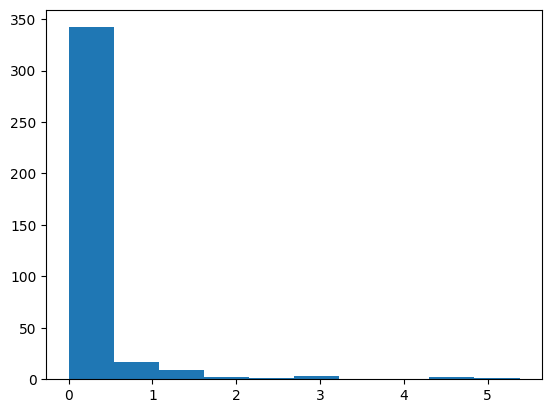

In [167]:
plt.hist(scrna_shared_ad.X.toarray().std(axis=0), bins=10)

(array([246.,  71.,  31.,  12.,   8.,   4.,   1.,   1.,   1.,   2.]),
 array([0.04216212, 0.28987876, 0.53759539, 0.785312  , 1.0330286 ,
        1.28074527, 1.52846181, 1.77617848, 2.02389503, 2.27161169,
        2.51932836]),
 <BarContainer object of 10 artists>)

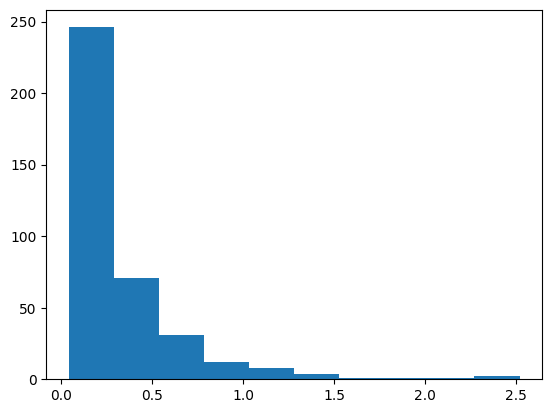

In [168]:
plt.hist(xenium_shared_ad.X.std(axis=0),bins=10)

In [169]:
# Make sure no column is static
mask = (
    (scrna_shared_ad.X.toarray().std(axis=0) > 0.1) 
    & (xenium_shared_ad.X.std(axis=0) > 0.15)
)
mask_genes = [gene if filter else None for gene, filter in zip(shared, mask)]
mask_genes = filter(lambda x: x, mask_genes)
mask_genes =list(mask_genes)
mask_genes.sort()
len(mask_genes), mask_genes

(164,
 ['ACTA2',
  'ADAM28',
  'ADAMTS1',
  'ADGRL4',
  'AGR3',
  'ALDH1A3',
  'ANGPT2',
  'APOA5',
  'APOLD1',
  'AQP9',
  'AR',
  'ARFGEF3',
  'ASCL1',
  'ASPN',
  'BAMBI',
  'BANK1',
  'BASP1',
  'BBOX1',
  'BCL2L11',
  'BMX',
  'BTNL9',
  'C5orf46',
  'C6orf118',
  'C7',
  'CAVIN1',
  'CCDC39',
  'CCNB2',
  'CD14',
  'CD163',
  'CD247',
  'CD274',
  'CD83',
  'CD86',
  'CDK1',
  'CENPF',
  'CFAP53',
  'CFB',
  'CFHR1',
  'CFHR3',
  'CFTR',
  'CHGA',
  'CLIC6',
  'COCH',
  'COL5A2',
  'CRISPLD2',
  'CSF2RA',
  'CTSK',
  'CXCL2',
  'CXCR4',
  'CYTIP',
  'DNAAF1',
  'DST',
  'EDNRB',
  'EGFL7',
  'EGFR',
  'EHF',
  'ELF5',
  'EPCAM',
  'ERBB2',
  'ERG',
  'ESR1',
  'FAS',
  'FBLN1',
  'FBN1',
  'FHL2',
  'FKBP11',
  'FOXA1',
  'FOXJ1',
  'FSTL3',
  'GATA2',
  'GATM',
  'GDF15',
  'GEM',
  'GPC1',
  'GPC3',
  'GPR183',
  'GPRC5A',
  'HAMP',
  'HAVCR2',
  'HEPACAM2',
  'HMGCS2',
  'HPX',
  'IGF1',
  'IL1R2',
  'IL1RL1',
  'IL2RA',
  'IL3RA',
  'IL7R',
  'INMT',
  'IRF8',
  'KCNK3',
  'K

In [170]:
scrna_shared_ad = scrna_shared_ad[:, mask].copy()
xenium_shared_ad = xenium_shared_ad[:, mask].copy()
print([scrna_shared_ad.shape, xenium_shared_ad.shape])

[(8997, 164), (27522, 164)]


### data preprocessing



We apply standard Scanpy preprocessing steps to shared/mask gene data<br>
#### **scrna_shared** ; **xenium_shared**

In [172]:
sc.pp.normalize_total(scrna_shared_ad)
sc.pp.log1p(scrna_shared_ad)
sc.pp.scale(scrna_shared_ad)

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [173]:
sc.pp.normalize_total(xenium_shared_ad)
sc.pp.log1p(xenium_shared_ad)
sc.pp.scale(xenium_shared_ad)

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [174]:
scrna_shared = scrna_shared_ad.X.copy()
xenium_shared = xenium_shared_ad.X.copy()

We  apply standard Scanpy preprocessing steps to all available RNA measurements and xenium measurements (not just the shared ones) to get two arrays, which are used for iterative refinement. Again if the input data is already processed, these steps can be skipped.
#### **scrna_active** and **xenium_active**, 


In [175]:
sc.pp.normalize_total(scrna_ad)
sc.pp.log1p(scrna_ad)
sc.pp.highly_variable_genes(scrna_ad, n_top_genes=5000)
# only retain highly variable genes
scrna_ad = scrna_ad[:, scrna_ad.var.highly_variable].copy()

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [176]:
sc.pp.normalize_total(xenium_ad)
sc.pp.log1p(xenium_ad)

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [177]:
scrna_ad

AnnData object with n_obs × n_vars = 8997 × 5000
    obs: 'data_type', 'louvain', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [178]:
xenium_ad

AnnData object with n_obs × n_vars = 27522 × 377
    obs: 'data_type'
    uns: 'log1p'

In [183]:
scrna_active = scrna_ad.X.toarray()
xenium_active = xenium_ad.X
scrna_active = scrna_active[:, scrna_active.std(axis=0) > 1e-5] 
xenium_active = xenium_active[:, xenium_active.std(axis=0) > 1e-5] 

In [184]:
print(scrna_active.shape)
print(xenium_active.shape)
print(scrna_shared.shape)
print(xenium_shared.shape)

(8997, 5000)
(27522, 377)
(8997, 164)
(27522, 164)


# Fitting MaxFuse


## Step I: preparations

We now have four arrays. rna_shared and merfish_shared are used for finding initial pivots, whereas rna_active and merfish_active are used for iterative refinement.

The main object for running MaxFuse pipeline is mf.model.Fusor, and its constructor takes the above four arrays as input.

If your data have not been clustered and annotated, you can leave labels1 and labels2 to be None, then MaxFuse will automatically run clustering algorithms to fill them in.

Optional: If your data have already been clustered (and you trust your annotation is optimal and should be used to guide the MaxFuse smoothing steps), you could supply them as numpy arrays to labels1 and labels2.

In [185]:
# call constructor for Fusor object
# which is the main object for running MaxFuse pipeline
fusor = mf.model.Fusor(
    shared_arr1=scrna_shared,
    shared_arr2=xenium_shared,
    active_arr1=scrna_active,
    active_arr2=xenium_active,
    labels1=None,
    labels2=None
)

To reduce computational complexity, we call split_into_batches to fit the batched version of MaxFuse.

Internally, MaxFuse will solve a few linear assignment problems of size n1 x n2, where n1 and n2 (with n1 < n2 by convention) are the sample sizes of the two modalities (after batching and metacell construction). max_outward_size specifis the maximum value of n1.

matching_ratio specifies approximately the ratio of n2/n1. The larger it is, the more candidate cells in the second modality MaxFuse will seek for to match each cell/metacell in the first modality.

metacell_size specifies the average size of the metacells in the first modality.

Since this integration process is larger (more merfish cells), we could increase the max_outward_size as long as the memory can accomodate that.

In [186]:
fusor.split_into_batches(
    max_outward_size=5000,
    matching_ratio=4,
    metacell_size=2,
    verbose=True
)

The first data is split into 1 batches, average batch size is 8997, and max batch size is 8997.
The second data is split into 1 batches, average batch size is 27522, and max batch size is 27522.
Batch to batch correspondence is:
  ['0<->0'].


The next step is to construct appropriate nearest-neighbor graphs for each modality with all features available. But before that, we plot the singular values of the two active arrays to determine how many principal components (PCs) to keep when doing graph construction.

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

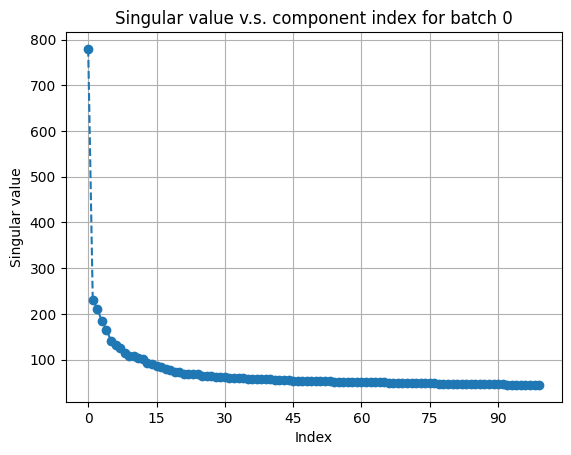

In [187]:
# plot top singular values of avtive_arr1 on a random batch
fusor.plot_singular_values(
    target='active_arr1',
    n_components=None # can also explicitly specify the number of components
)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

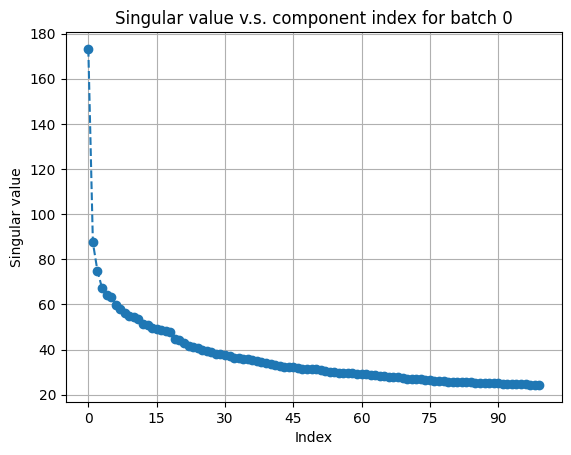

In [188]:
# plot top singular values of avtive_arr2 on a random batch
fusor.plot_singular_values(
    target='active_arr2',
    n_components=None
)

Inspecting the "elbows", we choose the number of PCs to be 30 for RNA and 15 for protein active data. We then call construct_graphs to compute nearest-neighbor graphs as needed.

In [189]:
fusor.construct_graphs(
    n_neighbors1=15,
    n_neighbors2=15,
    svd_components1=30,
    svd_components2=15,
    resolution1=2,
    resolution2=2,
    # if two resolutions differ less than resolution_tol
    # then we do not distinguish between then
    resolution_tol=0.1,
    verbose=True
)


Aggregating cells in arr1 into metacells of average size 2...
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...
Graph construction finished!
Clustering into metacells...
Now at batch 0...
Metacell clustering finished!
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...
Graph construction finished!
Clustering the graphs for cells in arr1...
Now at batch 0...
Graph clustering finished!
Constructing neighborhood graphs for cells in arr2...
Now at batch 0...
Graph construction finished!
Clustering the graphs for cells in arr2...
Now at batch 0...
Graph clustering finished!


## Step II: finding initial pivots

We then use shared arrays whose columns are matched to find initial pivots. Before we do so, we plot top singular values of two shared arrays to determine how many PCs to use.



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

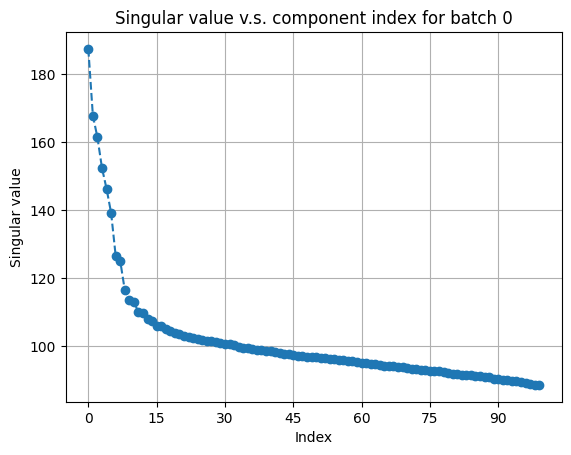

In [190]:
# plot top singular values of shared_arr1 on a random batch
fusor.plot_singular_values(
    target='shared_arr1',
    n_components=None,
)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

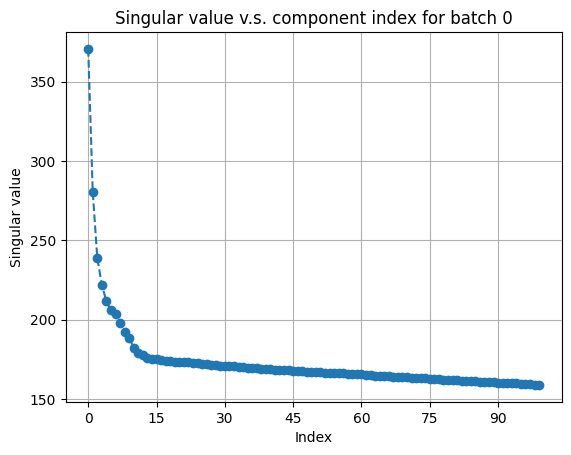

In [191]:
# plot top singular values of shared_arr2 on a random batch
fusor.plot_singular_values(
    target='shared_arr2',
    n_components=None
)

We choose to use 45 PCs for rna_shared and 30 PCs for protein_shared.



We then call find_initial_pivots to compute initial set of matched pairs. In this function, wt1 (resp. wt2) is a number between zero and one that specifies the weight on the smoothing target for the first (resp. second) modality. The smaller it is, the greater the strength of fuzzy smoothing. When the weight is one, then there is no smoothing at all, meaning the original data will be used.

Previously in the cite-seq example we used wt1 = 0.7 and wt2 = 0.7. In the case of integration that involves spatial data, we encourage using wt1 = 0.3 and wt2 = 0.3 since such datasets are usually "weaker" in linkage and requires stronger "smoothing".

In [192]:
fusor.find_initial_pivots(
    wt1=0.3, wt2=0.3,
    svd_components1=45, svd_components2=30
)

Now at batch 0<->0...
Done!


Now, we have a set of initial pivots that store the matched pairs when only the information in the shared arrays is used. The information on initial pivots are stored in the internal field fusor._init_matching that is invisible to users.

## Step III: finding refined pivots

We now use the information in active arrays to iteratively refine initial pivots. We plot the top canonical correlations to choose the best number of components in canonical correlation analysis (CCA).



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Canonical correlation v.s. component index for batch 0<->0'}, xlabel='Index', ylabel='Canonical correlation'>)

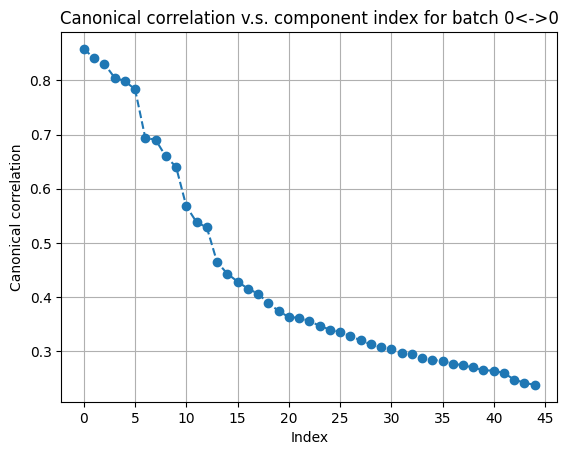

In [193]:
# plot top canonical correlations in a random batch
fusor.plot_canonical_correlations(
    svd_components1=50,
    svd_components2=None,
    cca_components=45
)

From the "elblow" above, we choose retain top 30 canonical scores.

Note: here that the n_iters number we choosed 1, as in low snr datasets (eg. Spatial-omis) increase amount of iteration might degrade the performance.



In [194]:
fusor.refine_pivots(
    wt1=0.3, wt2=0.3,
    svd_components1=40, svd_components2=None,
    cca_components=25,
    n_iters=1,
    randomized_svd=False, 
    svd_runs=1,
    verbose=True
)

Now at batch 0<->0...
Done!


The function filter_bad_matches filters away unreliable pivots and is helpful for the propagation step. filter_prop specifies approximately the proportion of pivots to be filtered away.

Note: here we can see filter_prop we increased the pivot filtering to 0.5 compared to previous example. We found harsher filtering for integrations that involves spatial-omics is more beneficial


In [195]:
fusor.filter_bad_matches(target='pivot', filter_prop=0.5)

Begin filtering...
Now at batch 0<->0...
2249/4498 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
4499/8997 cells in arr1 are selected as pivots.
2249/27522 cells in arr2 are selected as pivots.
Done!


In [196]:
pivot_matching = fusor.get_matching(order=(2, 1),target='pivot')

In [197]:
# We can inspect the first pivot pair.
[pivot_matching[0][0], pivot_matching[1][0], pivot_matching[2][0]]

[7205, 0, 0.7298914023238768]

In [199]:
[pivot_matching[0][2], pivot_matching[1][2], pivot_matching[2][2]]

[6548, 5, 0.7425381298396916]

Note: Since we have the refine_pivots now, we can theoratically co-embedding the full dataset into CCA space (as described in tutorial-1). However, in the case that invovles low-snr datasets (eg. spatial-omics), we do not suggest projecting all the cells into a common space without any filtering steps. We will describe this process after the propogation step.



## Step IV: propagation

Refined pivots can only give us a pivot matching that captures a subset of cells. In order to get a full matching that involves all cells during input, we need to call propagate.

Propagation uses active arrays, so we set the SVD components to be same as refine process

In [200]:
fusor.propagate(
    svd_components1=40, 
    svd_components2=None, 
    wt1=0.7,
    wt2=0.7,
)

Now at batch 0<->0...
Done!


We call filter_bad_matches with target=propagated to optionally filter away a few matched pairs from propagation.

Note: In the best scenario, we would prefer all cells in the full dataset can be matched accross modality. However, in the case that invovles low-snr datasets (eg. spatial-omics), many cells are noisy (or lack of information) and should not be included in downstream cross-modality analysis. We suggest in such scenarios, filter_prop should be set around 0.1-0.4.

In [201]:
fusor.filter_bad_matches(
    target='propagated',
    filter_prop=0.3
)

Begin filtering...
Now at batch 0<->0...
19265/27522 pairs of matched cells remain after the filtering.
Scoring matched pairs...
Done!


We use get_matching with target='full_data' to extract the full matching.

Because of the batching operation, the resulting matching may contain duplicates. The order argument determines how those duplicates are dealt with. order=None means doing nothing and returning the matching with potential duplicates; order=(1, 2) means returning a matching where each cell in the first modality contains at least one match in the second modality; order=(2, 1) means returning a matching where each cell in the second modality contains at least one match in the first modality.

Note: Since we filtered out some cell pairs here, not all cells in the full dataset has matches.

In [204]:
full_matching = fusor.get_matching(order=(2, 1), target='full_data')

Since we are doing order=(2, 1) here, the matching info is all the cells (10k) in mod 2 (protein) has at least one match cell in the RNA modality. Note that the matched cell in RNA could be duplicated, as protein cells could be matched to the same RNA cell. For a quick check on matching format:



In [205]:
matchResult = pd.DataFrame(list(zip(full_matching[0], full_matching[1], full_matching[2])), 
             columns = ['mod1_indx', 'mod2_indx', 'score'])
matchResult

,mod1_indx,mod2_indx,score
0,7205,0,0.729891
1,6548,5,0.742538
2,3606,6,0.713038
3,5380,8,0.594418
4,6574,10,0.747388
...,...,...,...
21132,7488,27516,0.700319
21133,3896,27517,0.597385
21134,1740,27518,0.383337
21135,4414,27519,-0.029251


In [206]:
len(set(matchResult.mod2_indx))

21137

In [207]:
scrna_ad[scrna_ad.obs.index[7205]].obs

,data_type,louvain,leiden
TCATATCGTTGTGTTG-1,scRNA,3,4


In [208]:
scRNA_louvain = pd.DataFrame(scrna_ad.obs["louvain"][matchResult.mod1_indx])
scRNA_leiden = pd.DataFrame(scrna_ad.obs["leiden"][matchResult.mod1_indx])
matchResult["scRNA_louvain"] = scRNA_louvain.louvain.values
matchResult["scRNA_leiden"] = scRNA_leiden.leiden.values
matchResult

,mod1_indx,mod2_indx,score,scRNA_louvain,scRNA_leiden
0,7205,0,0.729891,3,4
1,6548,5,0.742538,3,9
2,3606,6,0.713038,3,3
3,5380,8,0.594418,3,9
4,6574,10,0.747388,0,5
...,...,...,...,...,...
21132,7488,27516,0.700319,1,3
21133,3896,27517,0.597385,3,9
21134,1740,27518,0.383337,3,6
21135,4414,27519,-0.029251,6,4


In [209]:
xenium_ad.obs.index[0]

'aadomelj-1'

In [210]:
matchResult["xenium_cellid"]= xenium_ad.obs.index[matchResult.mod2_indx].values
matchResult

,mod1_indx,mod2_indx,score,scRNA_louvain,scRNA_leiden,xenium_cellid
0,7205,0,0.729891,3,4,aadomelj-1
1,6548,5,0.742538,3,9,aadpoijh-1
2,3606,6,0.713038,3,3,aadppfdo-1
3,5380,8,0.594418,3,9,aadppgea-1
4,6574,10,0.747388,0,5,aaeaccal-1
...,...,...,...,...,...,...
21132,7488,27516,0.700319,1,3,nhjlilkc-1
21133,3896,27517,0.597385,3,9,nhjlofbn-1
21134,1740,27518,0.383337,3,6,nhjmapda-1
21135,4414,27519,-0.029251,6,4,nhjmcomn-1


## export result to file

In [211]:
reindex_matchResult = matchResult.copy()
reindex_matchResult = reindex_matchResult.set_index("xenium_cellid")
reindex_matchResult

,mod1_indx,mod2_indx,score,scRNA_louvain,scRNA_leiden
xenium_cellid,,,,,
aadomelj-1,7205,0,0.729891,3,4
aadpoijh-1,6548,5,0.742538,3,9
aadppfdo-1,3606,6,0.713038,3,3
aadppgea-1,5380,8,0.594418,3,9
aaeaccal-1,6574,10,0.747388,0,5
...,...,...,...,...,...
nhjlilkc-1,7488,27516,0.700319,1,3
nhjlofbn-1,3896,27517,0.597385,3,9
nhjmapda-1,1740,27518,0.383337,3,6


In [212]:
labelTransferFile

'maxFuse_labelTransfer.tsv'

In [213]:
reindex_matchResult.to_csv(labelTransferFile, sep="\t")

## Step V: downstream analysis

As mentioned before, we want to draw a UMAP in the joint-embedding space, but for the filtered version of cells. For the low-snr datasets (eg. spatial-omics), we suggest only using cells that survived the propogation filtering step.



In [214]:
scrna_cca, xenium_cca = fusor.get_embedding(
    active_arr1=fusor.active_arr1,
    active_arr2=fusor.active_arr2[full_matching[1],:] # cells in xenium remained after filtering
)

In [215]:
dim_use = 15 # dimensions of the CCA embedding to be used for UMAP etc

cca_adata = ad.AnnData(
    np.concatenate((scrna_cca[:,:dim_use], xenium_cca[:,:dim_use]), axis=0), 
    dtype=np.float32
)
cca_adata.obs['data_type'] = ['scrna'] * scrna_cca.shape[0] + ['xenium'] * xenium_cca.shape[0]
# cca_adata.obs['cell_type'] = list(np.concatenate((labels_scrna,
#                                                  labels_merfish[full_matching[1]]), axis = 0))
#cca_adata.obs['x_centroids'] = list(np.concatenate(([0] * scrna_cca.shape[0],
#                                                  x_centroids_merfish[full_matching[1]]), axis = 0))
#cca_adata.obs['y_centroids'] = list(np.concatenate(([0] * scrna_cca.shape[0],
#                                                  y_centroids_merfish[full_matching[1]]), axis = 0))

/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


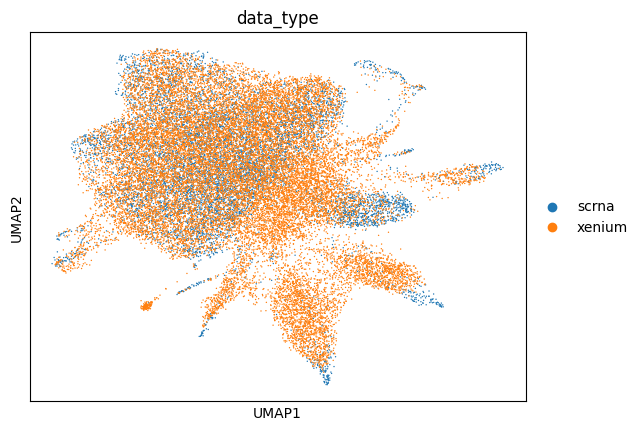

In [216]:
sc.pp.neighbors(cca_adata, n_neighbors=15)
sc.tl.umap(cca_adata)
sc.pl.umap(cca_adata, color='data_type', save='_MaxFuse_data_type.png')

In [217]:
#combine the initial data and create a UMAP of it not integrated
xenium_scrna_ad = ad.concat([xenium_shared_ad, scrna_shared_ad])

         Falling back to preprocessing with `sc.pp.pca` and default params.


/home/ubuntu/singlecellenv/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


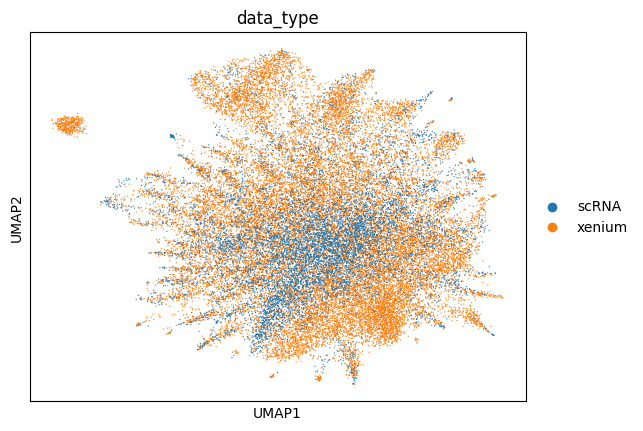

In [218]:
sc.pp.neighbors(xenium_scrna_ad, n_neighbors=15)
sc.tl.umap(xenium_scrna_ad)
sc.pl.umap(xenium_scrna_ad, color='data_type', save='_no_integration_data_type.png')